<a href="https://colab.research.google.com/github/shobhakulal79/shobha/blob/main/mini.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DATASET INFORMATION

First five rows:
             DateTime  Temperature   Humidity  Hour  DayOfWeek  Month  \
0 2025-01-01 00:00:00    25.865565  64.900632     0          2      1   
1 2025-01-01 01:00:00    25.689554  68.345962     1          2      1   
2 2025-01-01 02:00:00    27.592026  78.601414     2          2      1   
3 2025-01-01 03:00:00    29.526359  70.223206     3          2      1   
4 2025-01-01 04:00:00    27.367340  74.177785     4          2      1   

   IsWeekend  Electricity_Consumption  
0          0                 2.790337  
1          0                 1.936379  
2          0                 2.847883  
3          0                 2.793769  
4          0                 2.695352  

Dataset shape:
(4320, 8)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4320 entries, 0 to 4319
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Da

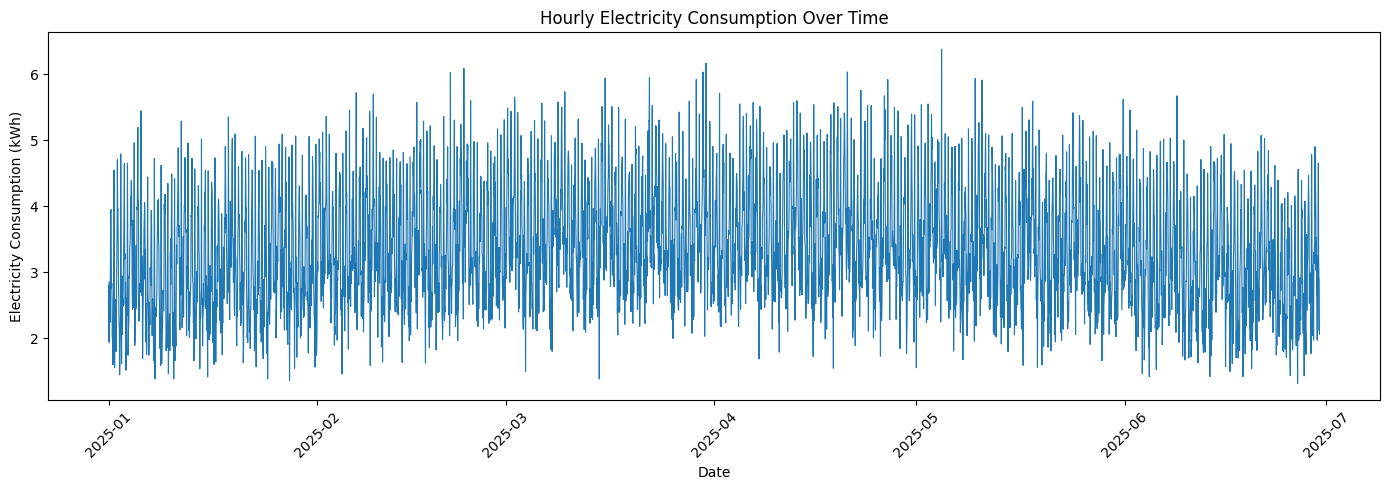

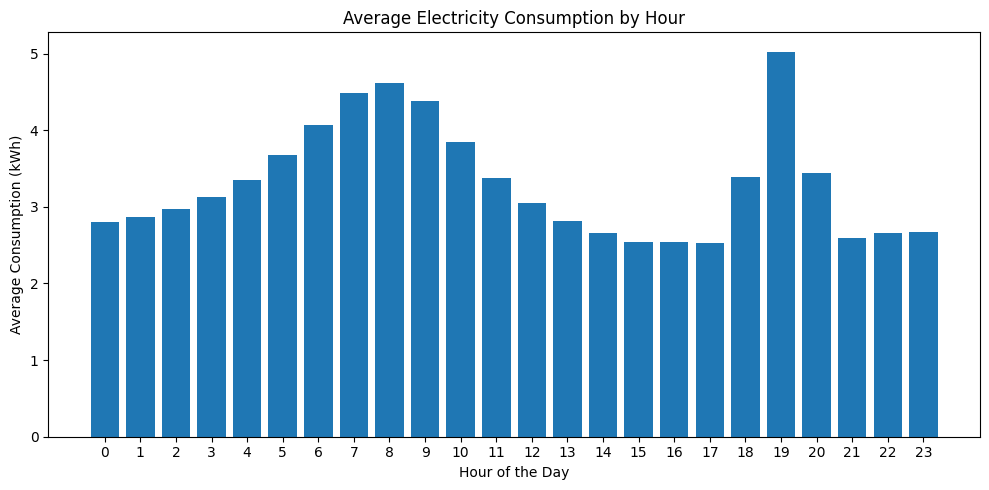

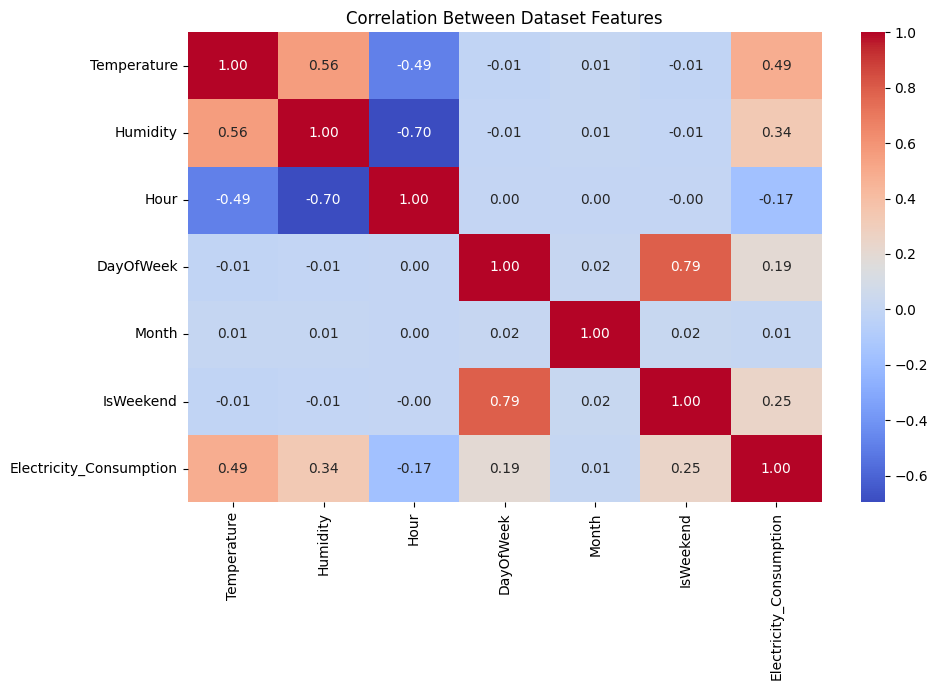

TRAIN-TEST SPLIT
Training samples: 3456
Testing samples: 864

Random Forest model trained successfully
PREDICTION RESULTS

First 10 actual and predicted values:
   Actual_Consumption  Predicted_Consumption
0               3.793                  3.299
1               2.943                  3.027
2               3.574                  3.225
3               3.292                  3.266
4               3.373                  3.878
5               3.980                  4.356
6               4.371                  4.422
7               5.370                  4.952
8               5.131                  4.919
9               4.054                  4.486
MODEL EVALUATION
Mean Absolute Error (MAE): 0.2996 kWh
Root Mean Squared Error (RMSE): 0.3773 kWh
R-squared (R2) Score: 0.8014


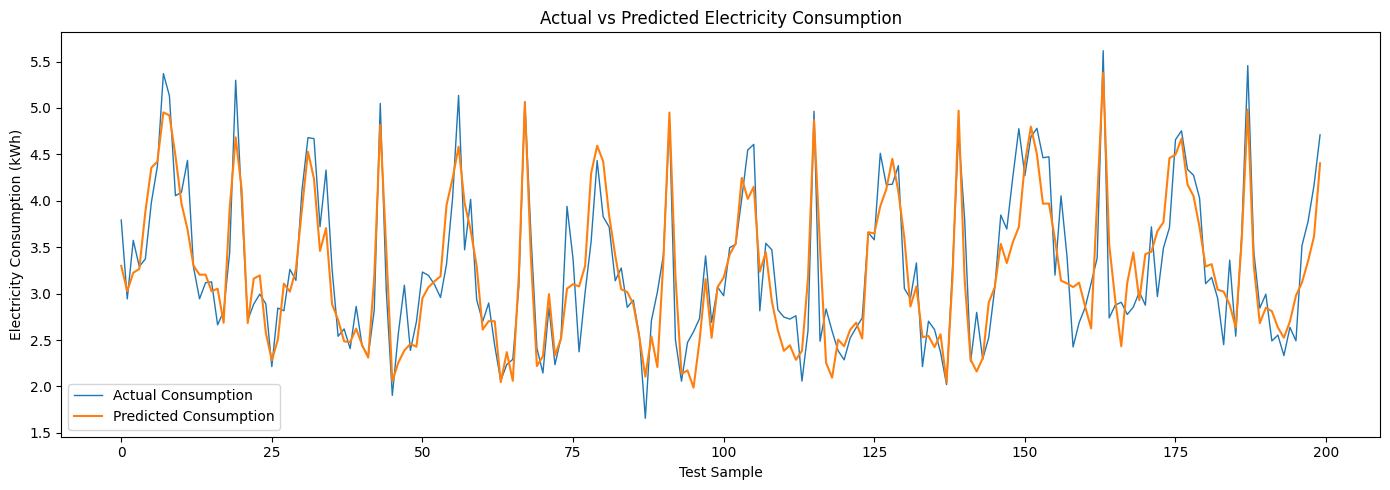

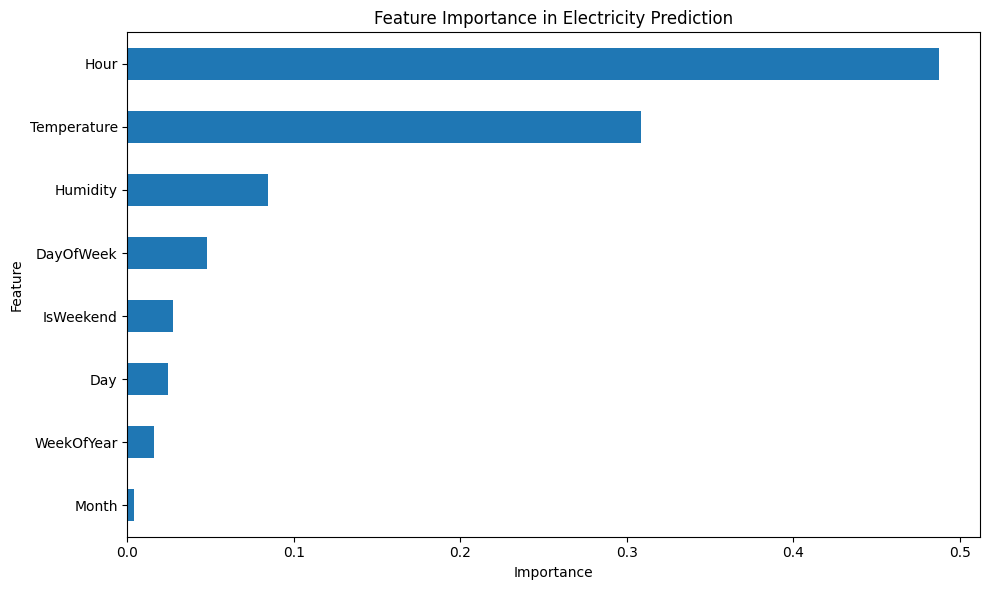

NEW PREDICTION
Predicted electricity consumption: 5.05 kWh

Prediction results saved successfully


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)
from sklearn.model_selection import train_test_split
np.random.seed(42)
date_range = pd.date_range(start="2025-01-01",periods=180 * 24,freq="h")
df = pd.DataFrame({"DateTime": date_range})
df["Temperature"] = (25+ 7 * np.sin(2 * np.pi * df["DateTime"].dt.dayofyear / 365)+ 3 * np.sin(2 * np.pi * df["DateTime"].dt.hour / 24)+ np.random.normal(0, 1.5, len(df)))
df["Humidity"] = np.clip(65 + 15 * np.sin(2 * np.pi * df["DateTime"].dt.hour / 24) + np.random.normal(0, 5, len(df)),20,100)
df["Hour"] = df["DateTime"].dt.hour
df["DayOfWeek"] = df["DateTime"].dt.dayofweek
df["Month"] = df["DateTime"].dt.month
df["IsWeekend"] = (df["DayOfWeek"] >= 5).astype(int)
morning_peak = 1.5 * np.exp(-((df["Hour"] - 8) ** 2) / 8)
evening_peak = 2.5 * np.exp(-((df["Hour"] - 19) ** 2) / 1)
temperature_effect = 0.12 * np.maximum(df["Temperature"] - 24, 0)
weekend_effect = 0.5 * df["IsWeekend"]
noise = np.random.normal(0, 0.35, len(df))
df["Electricity_Consumption"] = (2.0+ morning_peak+ evening_peak + temperature_effect + weekend_effect + noise)
df["Electricity_Consumption"] = (df["Electricity_Consumption"].clip(lower=0.2))
print("DATASET INFORMATION")
print("\nFirst five rows:")
print(df.head())
print("\nDataset shape:")
print(df.shape)
print("\nDataset information:")
df.info()
print("\nStatistical summary:")
print(df.describe())
print("DATA PREPROCESSING")
print("\nMissing values before cleaning:")
print(df.isnull().sum())
df = df.drop_duplicates()
numeric_columns=df.select_dtypes(include=np.number).columns
df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].median())
df["Day"] = df["DateTime"].dt.day
df["WeekOfYear"] = (df["DateTime"].dt.isocalendar().week.astype(int))
print("\nMissing values after cleaning:")
print(df.isnull().sum())
print("EXPLORATORY DATA ANALYSIS")
print("\nAverage electricity consumption:")
print(round(df["Electricity_Consumption"].mean(), 3),"kWh")
print("\nMaximum electricity consumption:")
print(round(df["Electricity_Consumption"].max(), 3),"kWh")
print("\nMinimum electricity consumption:")
print(round(df["Electricity_Consumption"].min(), 3),"kWh")
plt.figure(figsize=(14, 5))
plt.plot(df["DateTime"],df["Electricity_Consumption"],linewidth=0.8)
plt.title("Hourly Electricity Consumption Over Time")
plt.xlabel("Date")
plt.ylabel("Electricity Consumption (kWh)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
hourly_consumption = df.groupby("Hour")["Electricity_Consumption"].mean()
plt.figure(figsize=(10, 5))
plt.bar(hourly_consumption.index,hourly_consumption.values)
plt.title("Average Electricity Consumption by Hour")
plt.xlabel("Hour of the Day")
plt.ylabel("Average Consumption (kWh)")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()
correlation_columns = ["Temperature","Humidity","Hour","DayOfWeek","Month","IsWeekend","Electricity_Consumption"]
correlation_matrix = df[correlation_columns].corr()
plt.figure(figsize=(10, 7))
sns.heatmap(correlation_matrix,annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Between Dataset Features")
plt.tight_layout()
plt.show()
features = ["Temperature","Humidity","Hour","DayOfWeek","Month","IsWeekend","Day","WeekOfYear"]
X = df[features]
y = df["Electricity_Consumption"]
split_index = int(len(df) * 0.80)
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]
print("TRAIN-TEST SPLIT")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
model = RandomForestRegressor(n_estimators=150,max_depth=15,min_samples_split=4,min_samples_leaf=2,random_state=42,n_jobs=-1)
model.fit(X_train, y_train)
print("\nRandom Forest model trained successfully")
y_pred = model.predict(X_test)
results = pd.DataFrame({"Actual_Consumption": y_test.values,"Predicted_Consumption": y_pred})
print("PREDICTION RESULTS")
print("\nFirst 10 actual and predicted values:")
print(results.head(10).round(3))
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt( mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("MODEL EVALUATION")
print(f"Mean Absolute Error (MAE): {mae:.4f} kWh")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f} kWh")
print(f"R-squared (R2) Score: {r2:.4f}")
plt.figure(figsize=(14, 5))
plt.plot(y_test.values[:200],label="Actual Consumption",linewidth=1.)
plt.plot(y_pred[:200],label="Predicted Consumption",linewidth=1.5)
plt.title("Actual vs Predicted Electricity Consumption")
plt.xlabel("Test Sample")
plt.ylabel("Electricity Consumption (kWh)")
plt.legend()
plt.tight_layout()
plt.show()
importance = pd.Series(model.feature_importances_,index=features).sort_values(ascending=True)
plt.figure(figsize=(10, 6))
importance.plot(kind="barh")
plt.title("Feature Importance in Electricity Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()
new_data = pd.DataFrame({"Temperature": [30],"Humidity": [60],"Hour": [19],"DayOfWeek": [2],"Month": [7],"IsWeekend": [0],"Day": [15],"WeekOfYear": [28]})
predicted_consumption = model.predict(new_data)
print("NEW PREDICTION")
print("Predicted electricity consumption:",round(predicted_consumption[0], 3),"kWh")
results.to_csv("electricity_prediction_results.csv",index=False)
print("\nPrediction results saved successfully")